# Möbius transformations

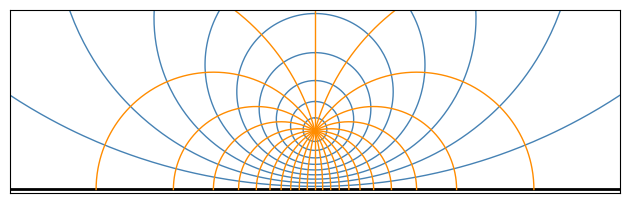

Möbius transformations have the form
$$T(z)=\frac{a z+b}{c z+d}.$$
It's not hard to show by direct computation that
$$T^{-1}(z) = \frac{dz-b}{-cz+a}.$$

In [77]:
var('a,b,c,d, z')
T(z) = (a*z+b)/(c*z+d)
TInv(z) = (d*z-b)/(-c*z+a)
TInv(T(z)).simplify_full()

z

We do need to assume that $ad-bc\neq0$ for this to be true, though. Otherwise, the function is a constant in disguise.

In [42]:
from math import isfinite

def rect_plot(
    T,
    x_range=(-2, 2),
    y_range=(-2, 2),
    x_lines=17,
    y_lines=17,
    points=400,
    plot_range=None,
    x_color="steelblue",
    y_color="darkorange",
    boundary_color="black",
    thickness=1,
    boundary_thickness=2,
    max_jump=None,
    aspect_ratio=1
):
    """
    Plot the image of a rectangular grid under a complex map T.

    T should accept a complex input z and return a complex output.
    x_range = (xmin, xmax)
    y_range = (ymin, ymax)

    Vertical grid lines are x = constant.
    Horizontal grid lines are y = constant.
    """

    xmin, xmax = x_range
    ymin, ymax = y_range

    xmin = float(xmin)
    xmax = float(xmax)
    ymin = float(ymin)
    ymax = float(ymax)

    def safe_T(z):
        try:
            w = CDF(T(z))
            X, Y = float(w.real()), float(w.imag())
            if isfinite(X) and isfinite(Y):
                return (X, Y)
        except Exception:
            pass
        return None

    def split_curve(samples):
        pieces = []
        current = []
        previous = None

        for p in samples:
            if p is None:
                if len(current) >= 2:
                    pieces.append(current)
                current = []
                previous = None
                continue

            if previous is not None and max_jump is not None:
                jump = sqrt((p[0] - previous[0])^2 + (p[1] - previous[1])^2)
                if jump > max_jump:
                    if len(current) >= 2:
                        pieces.append(current)
                    current = []

            current.append(p)
            previous = p

        if len(current) >= 2:
            pieces.append(current)

        return pieces

    def add_curve(g, samples, color, curve_thickness):
        for piece in split_curve(samples):
            g += line(piece, color=color, thickness=curve_thickness)
        return g

    g = Graphics()

    # Vertical grid lines: x = constant
    for j in range(x_lines):
        if x_lines == 1:
            x = (xmin + xmax)/2
        else:
            x = xmin + (xmax - xmin)*j/(x_lines - 1)

        is_boundary = j == 0 or j == x_lines - 1
        color = boundary_color if is_boundary else x_color
        curve_thickness = boundary_thickness if is_boundary else thickness

        samples = [
            safe_T(CDF(x, ymin + (ymax - ymin)*k/(points - 1)))
            for k in range(points)
        ]
        g = add_curve(g, samples, color, curve_thickness)

    # Horizontal grid lines: y = constant
    for j in range(y_lines):
        if y_lines == 1:
            y = (ymin + ymax)/2
        else:
            y = ymin + (ymax - ymin)*j/(y_lines - 1)

        is_boundary = j == 0 or j == y_lines - 1
        color = boundary_color if is_boundary else y_color
        curve_thickness = boundary_thickness if is_boundary else thickness

        samples = [
            safe_T(CDF(xmin + (xmax - xmin)*k/(points - 1), y))
            for k in range(points)
        ]
        g = add_curve(g, samples, color, curve_thickness)

    if plot_range is not None:
        (Xmin, Xmax), (Ymin, Ymax) = plot_range
        g.set_axes_range(Xmin, Xmax, Ymin, Ymax)

    g.set_aspect_ratio(aspect_ratio)

    return g

def disk_plot(
    T,
    z0=0,
    R=1,
    plot_range=None,
    circles=10,
    rays=24,
    points=400,
    circle_color="steelblue",
    ray_color="darkorange",
    boundary_color="black",
    thickness=1,
    boundary_thickness=2,
    max_jump=None,
    aspect_ratio=1,
    axes=False
):
    """
    Plot the image of the disk |z-z0| <= R under a complex map T.

    Parameters:
      T: function accepting a complex z and returning a complex value
      z0: center of the disk
      R: radius of the disk
      plot_range: None or ((xmin, xmax), (ymin, ymax))
      circles: number of interior radius curves
      rays: number of radial curves
      points: sample points per curve
      max_jump: optional threshold for breaking curves near poles/discontinuities
    """

    z0 = CDF(z0)
    R = float(R)

    def safe_T(z):
        try:
            w = CDF(T(z))
            x, y = float(w.real()), float(w.imag())
            if isfinite(x) and isfinite(y):
                return (x, y)
        except Exception:
            pass
        return None

    def disk_point(r, theta):
        return z0 + CDF(r * exp(I * theta))

    def split_curve(samples):
        pieces = []
        current = []
        previous = None

        for p in samples:
            if p is None:
                if len(current) >= 2:
                    pieces.append(current)
                current = []
                previous = None
                continue

            if previous is not None and max_jump is not None:
                jump = sqrt((p[0] - previous[0])^2 + (p[1] - previous[1])^2)
                if jump > max_jump:
                    if len(current) >= 2:
                        pieces.append(current)
                    current = []

            current.append(p)
            previous = p

        if len(current) >= 2:
            pieces.append(current)

        return pieces

    def add_curve(g, samples, color, curve_thickness):
        for piece in split_curve(samples):
            g += line(piece, color=color, thickness=curve_thickness)
        return g

    g = Graphics()

    # Images of concentric circles in the disk
    for j in range(1, circles + 1):
        r = R * j / circles
        color = boundary_color if j == circles else circle_color
        curve_thickness = boundary_thickness if j == circles else thickness

        samples = [
            safe_T(disk_point(r, 2*pi*k/(points - 1)))
            for k in range(points)
        ]
        g = add_curve(g, samples, color, curve_thickness)

    # Images of radial rays
    for j in range(rays):
        theta = 2*pi*j/rays
        samples = [
            safe_T(disk_point(R*k/(points - 1), theta))
            for k in range(points)
        ]
        g = add_curve(g, samples, ray_color, thickness)

    if plot_range is not None:
        (xmin, xmax), (ymin, ymax) = plot_range
        g.set_axes_range(xmin, xmax, ymin, ymax)

    g.set_aspect_ratio(aspect_ratio)
    g.axes(axes)

    return g

## Visualization

Recall that we visualize a complex function by illustrating its effect on various domains in the complex plane. I've written two functions named `rect_plot` and `disk_plot` to make it relatively easy to visualize the image of rectangular domains and polar domains respectively.

Here, for example, is the image of the square $[-1,1]\times[-1,1]$ under the action of the Möbius transformation
$$T(z) = i\frac{z+1}{2-z}.$$

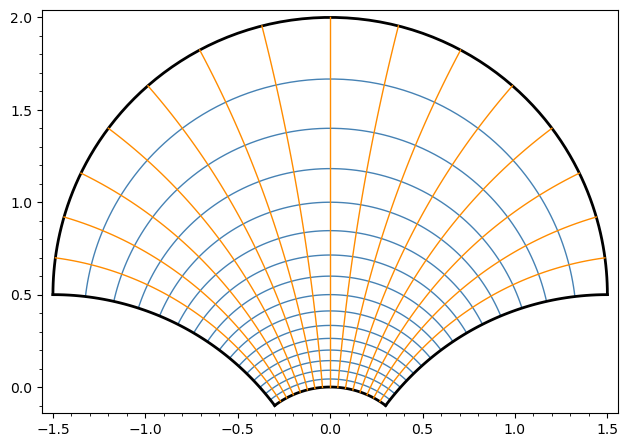

In [69]:
img = rect_plot(
    lambda z: I*(z+1)/(2-z),
    x_range=(-1,1),
    y_range=(-1,1),
    x_lines=17,
    y_lines=17,
    points=100,
)
show(img, frame=True, axes=False)

And here's the image of the unit disk under the transformation
$$T(z) = i\frac{z+1}{1-z}.$$

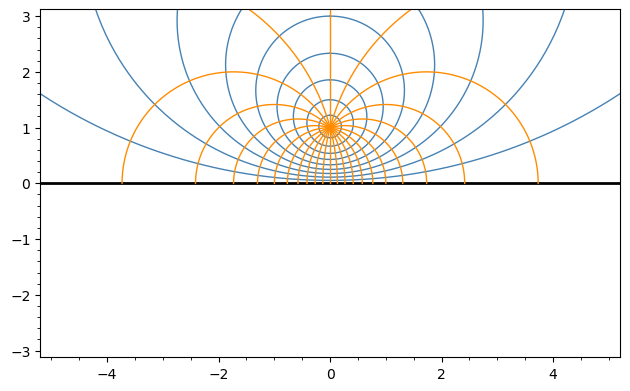

In [67]:
show(disk_plot(
    lambda z: I*(z+1)/(1-z),
    z0=0,
    R=1,
    plot_range=((-5, 5), (-3, 3)),
    circles=10,
    rays=24
), frame=True)

I guess we are curious to know how these types of images could come out of these types of functions??

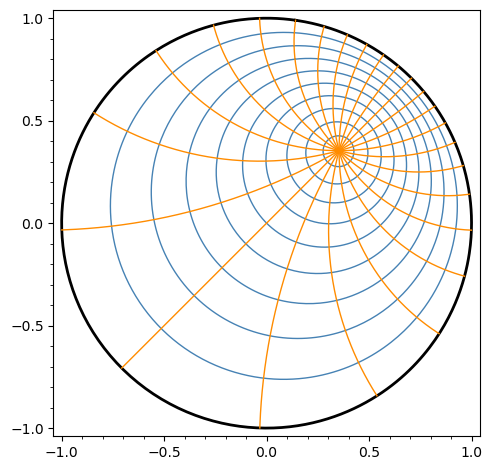

In [41]:
a = I/2
T = lambda z: e^(-I*pi/4)*(a-z)/(1-a.conjugate()*z)
show(disk_plot(
    T,
    z0=0,
    R=1,
    # plot_range=((-5, 5), (0, 3)),
    circles=10,
    rays=24
), frame=True)

## Circles and lines map to circles and lines

We've discussed some of this before but it's worth recalling some of the material as we go into it deeper this time.

> **Circles/Lines $\leftrightarrow$ circles/lines**: Let $LC$ denote the set of all lines and circles in the complex plane. Any Möbius transformation maps $LC$ to itself. That is, the image of any circle or line in the complex plane under a Möbius transformation is again a circle or line.

Our textbook calls the elements of $LC$ "generalized circles" and we'll see shortly why this might be a reasonable way to think of $LC$. First, let's reproduce [the textbook's explanation](https://complexanalysis.org/web/sec_reciprocal-transformation.html#sec_reciprocal-transformation-14) of the fact that $LC \leftrightarrow LC$ under multiplicative inversion. That is, the reciprocal function maps $LC$ to $LC$.

First, we note that the equation of any circle or line can be written in the form
$$
A(x^2+y^2) + Bx + Cy + D = 0,
$$
Where $A,B,C,$ and $D$ are real constants. We obtain a line precisely when $A\neq0$. We can translate this polar form easily enough:
$$
Ar^2+r(B\cos \theta +C\sin \theta) + D = 0\text{.}
$${#eq-inverted-circle}
Now, suppose that $z=re^{i\theta}$. Then,
$$\frac{1}{z} = \frac{1}{r}e^{-i\theta}.$$
Put another way, if we write $\frac{1}{z} = \rho e^{i\varphi}$, then 
$$\rho = \frac{1}{r} \text{ and } \varphi = -\theta.$$
Plugging that into @eq-inverted-circle, we get 
$$
A+\rho (B\cos \phi -C\sin \phi ) +D\rho ^2=0.
$$
This is again an equation of a line or circle, though which now depends on $D$, rather than $A$.

This much proves that 

> Inversion maps a circle or a line to a circle or line.

What about Möbius transformations more generally? Well, if $c\neq0$, then we can write
$$
\frac{az+b}{cz+d}
=
\frac{a}{c}
-
\frac{ad-bc}{c^2}\frac{1}{z+\frac{d}{c}}.
$$
Note that this is a composition of a shift, an inversion, a dialation/rotation with one more shift. Since each of those operations preserves $LC$, so does the Möbius transformation.

If $c=0$, it's even easier:
$$
\frac{az+b}{d} = \frac{a}{d}z + \frac{b}{d}.
$$

## Finding images under Möbius Transformations

Given a Möbius transformation and a circle or line, it's natural to ask for the image of that set under the action of the Möbius transformation. Well, a line is well known to be determined by two points and a circle by three. More generally, three distinct points uniquely determine a line or circle; we get a line exactly when the three points are colinear.

Often, we are interested in the image of a solid disk bound by a circle. That image could be either

- another disk,
- the exterior of another disk, or
- a half-plane.

We can find that image by simply finding the image of three points on the bounding circle. We can then examine the image of a point in the interior to characterize the image of the disk.

### Example 1

Find the image of the unit disk under the Möbius transformation 
$$T(z) = \frac{2z+3}{4z+5}.$$

**Solution**: We simply apply the transformation to 3 points in the unit circle:

In [123]:
def T(z): return (2*z + 3)/(4*z + 5)
image_points = [T(z) for z in [1,I,-1, 0]]
image_points

[5/9, -2/41*I + 23/41, 1, 3/5]

The first three of these points are clearly not colinear so they determine a circle, which is exactly the image of the unit circle under $T$. The point $0$ maps to $3/5$, which lies between $5/9$ and $1$. Thus, the interior of the unit disk maps onto the interior of this circle:

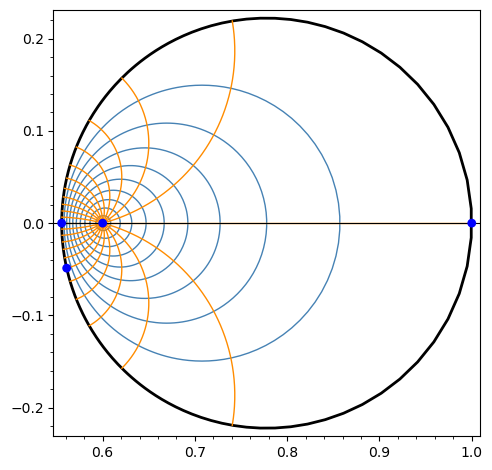

In [124]:
P = disk_plot(
    T,
    z0=0,
    R=1,
    circles=10,
    rays=24,
)
Q = point(
    [(real(z), imag(z)) for z in image_points],
    color="blue",
    size=40,
    zorder=10
)
show(P+Q, frame=True)

In [125]:
def T(z): return (z - 1)/(z - I)
[T(z) for z in [1,-I,-1]]

[0, -1/2*I + 1/2, -I + 1]

In [107]:
T(0)

-I

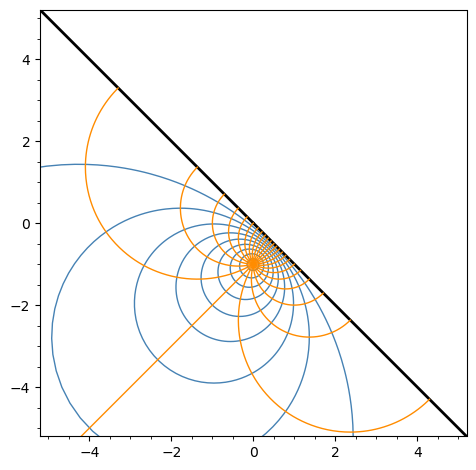

In [126]:
show(disk_plot(
    T,
    z0=0,
    R=1,
    plot_range=((-5, 5), (-5, 5)),
    circles=10,
    rays=24,
    max_jump=10
), frame=True)